<a href="https://colab.research.google.com/github/Solu-victoria/SS-DLI-Research/blob/main/Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import userdata
email = userdata.get('gb_email')
name = userdata.get('gb_name')
secret_key = userdata.get('gb_secret_key')

In [3]:
!git clone https://{secret_key}@github.com/Solu-victoria/SS-DLI-Research.git

Cloning into 'SS-DLI-Research'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 153 (delta 43), reused 102 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 1.55 MiB | 10.10 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [4]:
!git config --global user.email {email}
!git config --global user.name {name}

In [5]:
%cd SS-DLI-Research/

/content/SS-DLI-Research


In [102]:
!git add .

In [103]:
!git commit -m '500 steps per ep done and results images uploaded'

[main 7938e97] 500 steps per ep done and results images uploaded
 14 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 images/v2/500_steps_per_ep/experiment 1.1-v2-500stepsperep.png
 create mode 100644 images/v2/500_steps_per_ep/experiment 1.2-v2-500stepsperep.png
 create mode 100644 images/v2/500_steps_per_ep/experiment 2-v2-500stepsperep.png
 create mode 100644 images/v2/500_steps_per_ep/experiment 3-v2-500stepsperep.png
 create mode 100644 models/v2/500_steps_per_ep/baseline/run_1.pth
 create mode 100644 models/v2/500_steps_per_ep/baseline/run_2.pth
 create mode 100644 models/v2/500_steps_per_ep/baseline/run_3.pth
 create mode 100644 models/v2/500_steps_per_ep/baseline/run_4.pth
 create mode 100644 models/v2/500_steps_per_ep/baseline/run_5.pth
 create mode 100644 models/v2/500_steps_per_ep/multi/run_1.pth
 create mode 100644 models/v2/500_steps_per_ep/multi/run_2.pth
 create mode 100644 models/v2/500_steps_per_ep/multi/run_3.pth
 create mode 100644 models/v2/500_ste

In [104]:
!git push

Enumerating objects: 29, done.
Counting objects: 100% (29/29), done.
Delta compression using up to 2 threads
Compressing objects: 100% (24/24), done.
Writing objects: 100% (24/24), 496.16 KiB | 19.08 MiB/s, done.
Total 24 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Solu-victoria/SS-DLI-Research.git
   478e3e9..7938e97  main -> main


In [57]:
!git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 302.03 KiB | 3.21 MiB/s, done.
From https://github.com/Solu-victoria/SS-DLI-Research
   6f95b31..a093db0  main       -> origin/main
Updating 6f95b31..a093db0
Fast-forward
 Experiments.ipynb | 4207 ++++++++++++++++++++++++++---------------------------
 1 file changed, 2080 insertions(+), 2127 deletions(-)


## EXPERIMENT 1 — Learning Curve Comparison

In [61]:
from train import run_train_experiment
import numpy as np
import matplotlib.pyplot as plt

In [62]:
baseline_runs, multi_runs = run_train_experiment(num_runs=5, episodes=200, num_steps_per_ep=500)


Run 1/5
Baseline | Episode 0 | Reward: 36.47
Baseline | Episode 1 | Reward: 26.00
Baseline | Episode 2 | Reward: 59.20
Baseline | Episode 3 | Reward: 39.50
Baseline | Episode 4 | Reward: -19.94
Baseline | Episode 5 | Reward: 53.01
Baseline | Episode 6 | Reward: -5.50
Baseline | Episode 7 | Reward: 49.61
Baseline | Episode 8 | Reward: 75.50
Baseline | Episode 9 | Reward: 60.50
Baseline | Episode 10 | Reward: 54.85
Baseline | Episode 11 | Reward: -10.00
Baseline | Episode 12 | Reward: -71.50
Baseline | Episode 13 | Reward: 94.81
Baseline | Episode 14 | Reward: -10.16
Baseline | Episode 15 | Reward: 77.65
Baseline | Episode 16 | Reward: 50.00
Baseline | Episode 17 | Reward: 8.02
Baseline | Episode 18 | Reward: 23.90
Baseline | Episode 19 | Reward: 48.50
Baseline | Episode 20 | Reward: 55.82
Baseline | Episode 21 | Reward: 57.51
Baseline | Episode 22 | Reward: 53.00
Baseline | Episode 23 | Reward: -27.99
Baseline | Episode 24 | Reward: 26.00
Baseline | Episode 25 | Reward: -35.50
Baseline

In [65]:
baseline_mean = baseline_runs.mean(axis=0)
baseline_std = baseline_runs.std(axis=0)

multi_mean = multi_runs.mean(axis=0)
multi_std = multi_runs.std(axis=0)

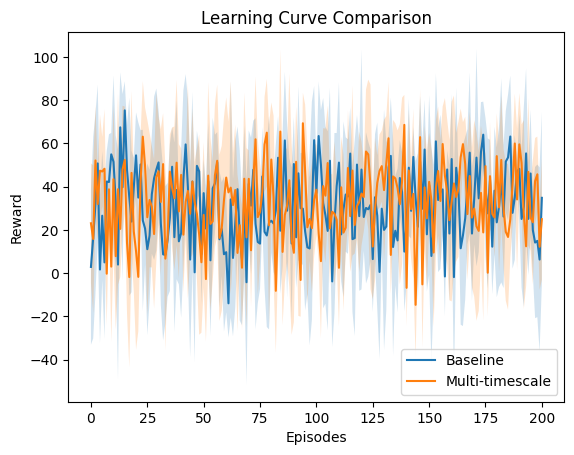

In [68]:
plt.figure()

plt.plot(baseline_mean, label="Baseline")
plt.fill_between(
    range(len(baseline_mean)),
    baseline_mean - baseline_std,
    baseline_mean + baseline_std,
    alpha=0.2
)

plt.plot(multi_mean, label="Multi-timescale")
plt.fill_between(
    range(len(multi_mean)),
    multi_mean - multi_std,
    multi_mean + multi_std,
    alpha=0.2
)

plt.legend()
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Learning Curve Comparison")

plt.show()

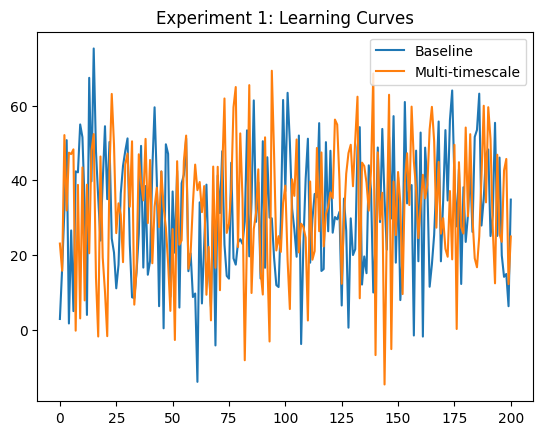

In [69]:
# baseline_mean = baseline_runs.mean(axis=0)
# multi_mean = multi_runs.mean(axis=0)

plt.plot(baseline_mean, label="Baseline")
plt.plot(multi_mean, label="Multi-timescale")

plt.legend()
plt.title("Experiment 1: Learning Curves")
plt.show()
# print(baseline_mean)

## EXPERIMENT 2 — Learner Type Analysis

In [79]:
from env import StudentEnv
from agent import Agent

def evaluate_student(agent, env, steps=100):
    state = env.reset()
    total_reward = 0

    for _ in range(steps):
        action = agent.select_action(state)
        state, reward, _, _ = env.step(action)
        total_reward += reward

    return total_reward

In [81]:
baseline_agent = Agent(state_dim=2, action_dim=4)
multi_agent = Agent(state_dim=4, action_dim=4)

baseline_agent.load("models/v2/500_steps_per_ep/baseline/run_1.pth")
multi_agent.load("models/v2/500_steps_per_ep/multi/run_1.pth")

baseline_agent.epsilon = 0.0
multi_agent.epsilon = 0.0

In [100]:
# Slow but strong learner
baseline_env = StudentEnv(multi_timescale=False)
baseline_env.true_ability = 0.8
baseline_env.true_speed = 0.3

baseline_score = evaluate_student(baseline_agent, baseline_env)

multitime_env = StudentEnv(multi_timescale=True)
multitime_env.true_ability = 0.8
multitime_env.true_speed = 0.3

multitime_score = evaluate_student(multi_agent, multitime_env)
print("Baseline:", baseline_score)
print("Multi:", multitime_score)

Baseline: 8.500660503076094
Multi: 3.8527482011418823


## EXPERIMENT 3 — Stability / Variance

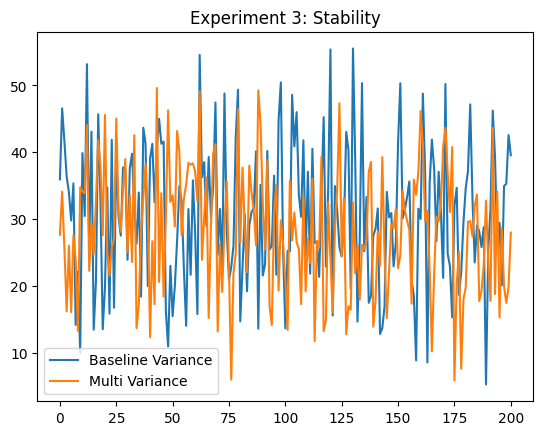

In [101]:
baseline_std = baseline_runs.std(axis=0)
multi_std = multi_runs.std(axis=0)

plt.plot(baseline_std, label="Baseline Variance")
plt.plot(multi_std, label="Multi Variance")

plt.legend()
plt.title("Experiment 3: Stability")
plt.show()